In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch as th
import kan   as kn
from kan.utils import create_dataset_from_data


device = "cuda"

## 1 Teorema da Representação de Kolmogorov-Arnold

Uma função multivariável $f$, contínua em um certo intervalo, pode ser representada como uma composição de somas de funções univariadas contínuas:

$$
\begin{align}
    f(x_1, x_2, \cdots, x_n) &= \displaystyle\sum_{q=1}^m \Phi\left( \displaystyle\sum_{p=1}^n \phi_{q, p} (x_p) \right) \\
    &= \Phi_1 \big(\phi_{1,1}(x_1) + \phi_{1,2}(x_2) + \cdots + \phi_{1,n}(x_n) \big) + \\
    &+ \Phi_2 \big(\phi_{2,1}(x_1) + \phi_{2,2}(x_2) + \cdots + \phi_{2,n}(x_n) \big) + \\
    &\ \ \vdots \\
    &+ \Phi_m \big(\phi_{m,1}(x_1) + \phi_{m,2}(x_2) + \cdots + \phi_{m,n}(x_n) \big) + \\
\end{align}
$$

Seja o seguinte exemplo com $n=2$ e $m = 5$:
![SegmentLocal](kan_example.gif "segment")

## 2 Curvas de Bézier

As curvas de Bézier são curvas paramétricas utilizadas em problemas de interpolação. A partir de um conjunto de $n+1$ pontos de controle $P_i$, $0\leq i \leq n$, obtém-se um polinômio de grau $n$ que liga os pontos $P_0$ e $P_n$ sem necessariamente interceptar os pontos intermediários.

Para entender o procedimento de cálculo das curvas de Bézier, analisemos os seguintes casos particulares:

* __Curva linear__: Pontos $\mathbf{P_0}$ e $\mathbf{P_1}$, $n = 1$
$$
\begin{align}
\mathbf{B}_{\mathbf{P_0}, \mathbf{P_1}}(t) &= \mathbf{P_0} + (\mathbf{P_1} - \mathbf{P_0})t  \\
&= t\mathbf{P_1} + (1-t)\mathbf{P_0}
\end{align}
$$

* __Curva quadrática__: Pontos $\mathbf{P_0}$, $\mathbf{P_1}$ e $\mathbf{P_2}$, $n = 2$
$$
\begin{align}
    \mathbf{B}_{\mathbf{P_0}, \mathbf{P_1}, \mathbf{P_2}}(t) &= t\mathbf{B}_{\mathbf{P_1}, \mathbf{P_2}}(t) + (1-t)\mathbf{B}_{\mathbf{P_0}, \mathbf{P_1}}(t)  \\
    &= t(t\mathbf{P_2} + (1-t)\mathbf{P_1}) + (1-t)(t\mathbf{P_1} + (1-t)\mathbf{P_0})  \\
    &= t^2 \mathbf{P_2} + 2(1-t)t\mathbf{P_1} + (1-t)^2 \mathbf{P_0}
\end{align}
$$

* __Curva cúbica__: Pontos $\mathbf{P_0}$, $\mathbf{P_1}$, $\mathbf{P_2}$ e $\mathbf{P_3}$, $n = 3$
$$
\begin{align}
    \mathbf{B}_{\mathbf{P_0}, \mathbf{P_1}, \mathbf{P_2}, \mathbf{P_3}}(t) &= t\mathbf{B}_{\mathbf{P_1}, \mathbf{P_2}, \mathbf{P_3}}(t) + (1-t)\mathbf{B}_{\mathbf{P_0}, \mathbf{P_1}, \mathbf{P_2}}(t)  \\
    &= t(t^2 \mathbf{P_3} + 2(1-t)t\mathbf{P_2} + (1-t)^2 \mathbf{P_1}) + (1-t)(t^2 P_2 + 2(1-t)t\mathbf{P_1} + (1-t)^2 \mathbf{P_0})  \\
    &= t^3 \mathbf{P_3} + 3(1-t)t^2 \mathbf{P_2} + 3(1-t)^2t\mathbf{P_1} + (1-t)^3\mathbf{P_0}
\end{align}
$$

No caso geral, uma curva de Bézier de ordem $n$ é escrita como uma composição de polinômios de Bernstein $b_{i,n}(t)$:

$$
\begin{align}
    \mathbf{B}(t) &= \displaystyle\sum_{i=0}^{n}  \binom{n}{i}(1-t)^{n-1}t^î \mathbf{P_i} \\
    &= \displaystyle\sum_{i=0}^{n} b_{i, n}(t)\mathbf{P_i}
\end{align}
$$

In [7]:
from scipy.special import binom

def bernstein_poly(t, i, n):
    return binom(n, i) * t**i * (1-t)**(n-i)

def bezier(t, P):
    n = P.shape[0] - 1

    x_b = np.sum(np.array( [ bernstein_poly(t, i, n)*P[i,0] for i in range(n+1) ] ), axis = 0)
    y_b = np.sum(np.array( [ bernstein_poly(t, i, n)*P[i,1] for i in range(n+1) ] ), axis = 0)
    
    return x_b, y_b

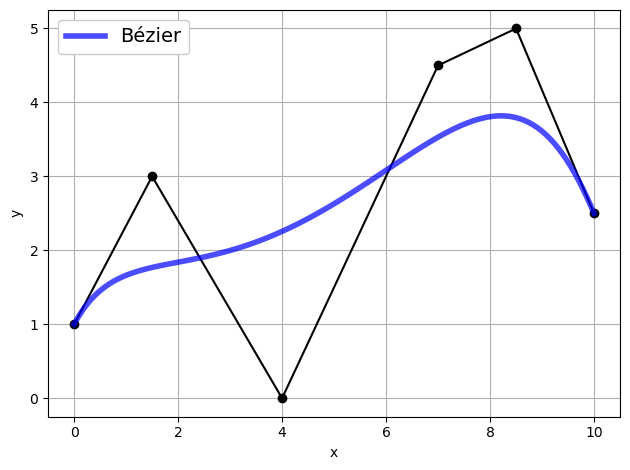

In [8]:
P = np.array([ [0,1], [1.5, 3], [4,0], [7, 4.5], [8.5, 5], [10, 2.5] ])

n = P.shape[0] - 1

t = np.linspace(0, 1, 100)
x, y = bezier(t, P)

plt.plot(P[:,0], P[:,1], "-ko")
plt.plot(x, y, "b", lw=4, alpha=0.7, label = "Bézier")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(fontsize = 14, framealpha = 1)
plt.grid()
plt.tight_layout()

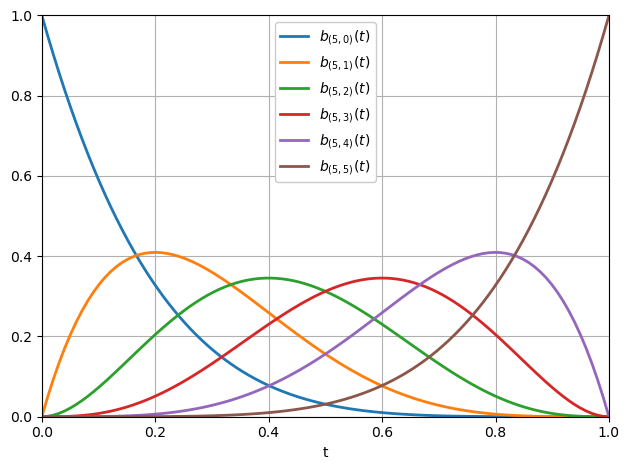

In [9]:
for i in range(n+1):
    plt.plot(t, bernstein_poly(t, i, n), lw = 2, label = r"$b_{"+f"{n, i}"+"}(t)$")

plt.ylim(0, 1)
plt.xlim(0, 1)
plt.legend(framealpha = 1)
plt.xlabel("t")
plt.grid()
plt.tight_layout()

## 3 B-splines

Como a ordem do polinômio de uma curva de Bézier é diretamente proporcional ao número de pontos de controle, nos casos em que muitos pontos de controle estão presentes o custo computacional para o cálculo dessas curvas aumenta consideravelmente. Outro ponto importante é o fato de que qualquer alteração feita em um ponto de controle específico modifica toda a curva de Bézier.

Um método para contornar este problema consiste nas curvas B-spline, em que para uma interpolação com $n+1$ pontos de controle utiliza-se uma curva composta pela concatenação de $n + 1 - k$ curvas de Bézier, em que $k$ é a ordem do polinômio que compõe cada uma.

Os pontos em que cada curva se conecta são denominados de nós, e uma B-spline composta por polinômios de ordem $k$ possui continuidade do tipo $C^{k-2}$ nos nós de conexão.

Uma curva B-spline de ordem $k$ é definida como:
$$
\mathbf{S}(t) = \displaystyle\sum_{i=0}^n N_{i,k}(t)\mathbf{P}_i
$$

em que $\mathbf{P}_i$, $0 \leq i \leq n$, são os pontos de controle, e $N_{i,k}(t)$ os polinômios da base, obtidos pela fórmula de recursão de Cox-de Boor:
$$
\begin{align}
    N_{i,0}(t) &= \begin{cases} 1\ ,\ \text{se}\ t_i \leq t \leq t_{i+1} \\ 0\ ,\ \text{c.c.} \end{cases} \\
    N_{i,k}(t) &= \dfrac{t-t_i}{t_{i+k} - t_i} N_{i,k-1}(t) +  \dfrac{t_{i+k+1} - t}{t_{i+k+1} - t_{i+1}} N_{i+1,k-1}(t) 
\end{align}
$$

Os nós correspondem aos pontos parametrizados por $t_0, t_1, \cdots, t_{k-1}, t_k, t_{k+1}, \cdots, t_{k+n+1}$

NameError: name 'BSpline' is not defined

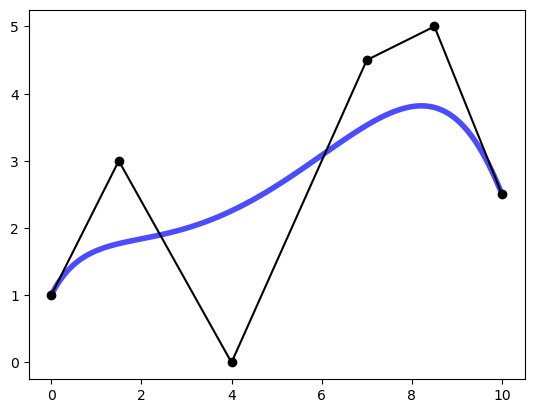

In [10]:
P = np.array([ [0,1], [1.5, 3], [4,0], [7, 4.5], [8.5, 5], [10, 2.5] ])

t = np.linspace(0, 1, 100)
x, y = bezier(t, P)
plt.plot(x, y, "b", lw=4, alpha=0.7, label = "Bézier")
plt.plot(P[:,0], P[:,1], "-ko")

# B-spline
t_knot = np.array([0, 0, 0, 0, 3, 6, 9, 9, 9, 9])
t = np.linspace(0, np.max(t_knot), 100)
k = 3

spl = BSpline(t_knot, P, k, extrapolate = False)

plt.plot(spl(t)[:,0], spl(t)[:,1], 'r-', lw=4, alpha=0.7, label='B-spline')
plt.plot(spl(t_knot)[:,0], spl(t_knot)[:,1], "go")

plt.ylabel("y")
plt.xlabel("x")
plt.legend(framealpha = True, fontsize = 14)
plt.grid()
plt.tight_layout()

## 4 Exemplo

In [11]:
f    = lambda x: th.exp(th.sin(th.pi*x + x**2))
size = 5000

x = 5*th.rand((size, 1), device = device)
n = th.normal(0, 0.1, size = (size, 1), device = device)
y = f(x) + n

dataset = create_dataset_from_data(x, y, train_ratio = 0.95, device=device)

In [52]:
model.update_grid(dataset['train_input'])
print(model.act_fun[0].grid)

Parameter containing:
tensor([[-3.9983e+00, -2.9985e+00, -1.9988e+00, -9.9909e-01,  6.3727e-04,
          9.9502e-01,  2.0376e+00,  3.0128e+00,  3.9778e+00,  4.9993e+00,
          5.9990e+00,  6.9987e+00,  7.9985e+00,  8.9982e+00]], device='cuda:0')


In [49]:
model = kn.KAN(width = [1, 2, 1], grid = 5, k = 4, seed = 10, device = device)
print(model.act_fun[0].grid)

checkpoint directory created: ./model
saving model version 0.0
Parameter containing:
tensor([[-2.6000, -2.2000, -1.8000, -1.4000, -1.0000, -0.6000, -0.2000,  0.2000,
          0.6000,  1.0000,  1.4000,  1.8000,  2.2000,  2.6000]],
       device='cuda:0')


checkpoint directory created: ./model
saving model version 0.0
Parameter containing:
tensor([[-2.2000, -1.8000, -1.4000, -1.0000, -0.6000, -0.2000,  0.2000,  0.6000,
          1.0000,  1.4000,  1.8000,  2.2000]], device='cuda:0')


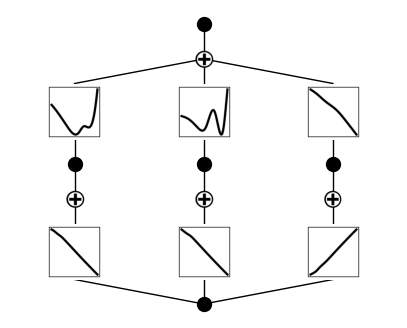

In [12]:
model = kn.KAN(width = [1, 3, 1], grid = 5, k = 3, seed = 0, device = device)
print(model.act_fun[0].grid)

model(dataset['train_input'])
model.plot(beta=100)

In [902]:
def train_mse():
    with th.no_grad():
        predictions = model(dataset['train_input'])
        mse = th.nn.functional.mse_loss(predictions, dataset['train_label'])
    return mse

def test_mse():
    with th.no_grad():
        predictions = model(dataset['test_input'])
        mse = th.nn.functional.mse_loss(predictions, dataset['test_label'])
    return mse

| train_loss: 2.25e-01 | test_loss: 2.18e-01 | reg: 1.20e+01 | : 100%|█| 2000/2000 [00:32<00:00, 62.


saving model version 0.1
Parameter containing:
tensor([[-2.9976e+00, -1.9980e+00, -9.9845e-01,  1.1348e-03,  1.0078e+00,
          1.9850e+00,  3.0448e+00,  4.0322e+00,  4.9991e+00,  5.9986e+00,
          6.9982e+00,  7.9978e+00]], device='cuda:0')


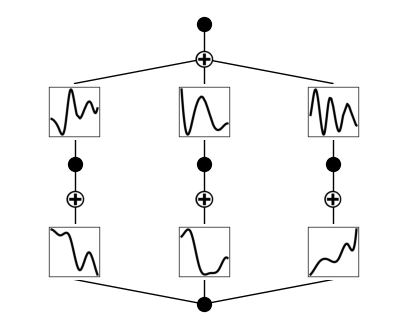

In [903]:
# train the model
model.train()

results = model.fit(dataset, opt = "Adam", steps = 2_000, lamb = 0.001, loss_fn = th.nn.MSELoss(), lr = 5e-3, metrics = (train_mse, test_mse))
model.plot()
print(model.act_fun[0].grid)
#mode.prune()

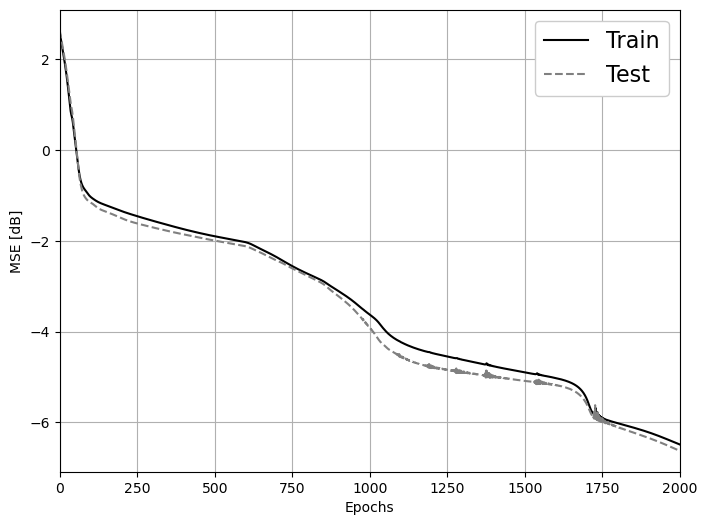

In [904]:
plt.figure(figsize = (8, 6))
plt.plot(10*np.log10(results["train_loss"]), color = "k", label = "Train")
plt.plot(10*np.log10(results["test_loss"]), "--", color = "gray", label = "Test")

plt.xlim(0, 2000)
plt.xlabel("Epochs")
plt.ylabel("MSE [dB]")
plt.legend(fontsize = 16, framealpha = 1, loc = "upper right")
plt.grid()

In [905]:
with th.no_grad():
    y_kan = model(x)

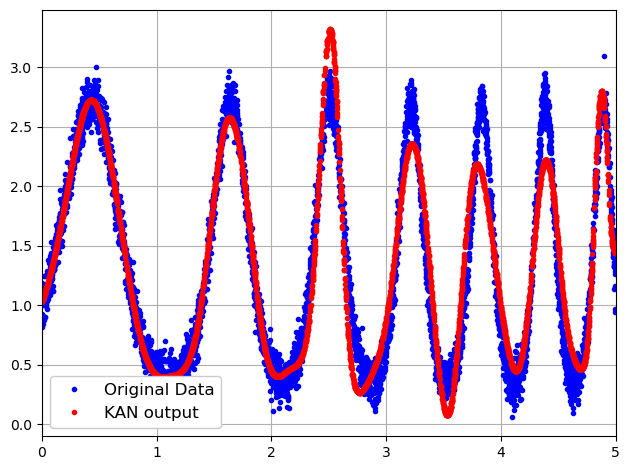

In [906]:
plt.plot(x.detach().cpu().numpy(), y.detach().cpu().numpy(), "bo", ms = 3, label = "Original Data")
plt.plot(x.detach().cpu().numpy(), y_kan.detach().cpu().numpy(), "ro", ms = 3, label = "KAN output")
plt.legend(framealpha = 1, fontsize = 12, loc = "lower left")
plt.xlim(0, 5)
plt.grid()
plt.tight_layout()

In [907]:
10*th.log10(th.mean(th.abs(y_kan - f(x))**2)).item()

-13.897764682769775

In [908]:
x, y = model.get_fun(1,3,0)
plt.close()
plt.plot(x, y)

IndexError: index 3 is out of bounds for dimension 2 with size 3

In [761]:
# Symbolic fitting...

In [774]:
model.suggest_symbolic(0,0,0,a_range = (0, 5))

    function  fitting r2   r2 loss  complexity  complexity loss  total loss
0          0    0.000000  0.000014           0                0    0.000003
1          x    0.911376 -3.496004           1                1    0.100799
2        1/x    0.918953 -3.624922           2                2    0.875016
3      1/x^2    0.918953 -3.624914           2                2    0.875017
4  1/sqrt(x)    0.918949 -3.624847           2                2    0.875031


('0',
 (<function kan.utils.<lambda>(x)>,
  <function kan.utils.<lambda>(x)>,
  0,
  <function kan.utils.<lambda>(x, y_th)>),
 0.0,
 0)

In [775]:
formula = model.symbolic_formula()[0][0]
#ex_round(formula,6)

In [776]:
formula

0

In [762]:
model.auto_symbolic()
model.symbolic_formula()[0][0]

fixing (0,0,0) with 0, r2=0.0, c=0
fixing (0,0,1) with 0, r2=0.0, c=0
fixing (0,0,2) with 0, r2=0.0, c=0
fixing (0,0,3) with 0, r2=0.0, c=0
fixing (1,0,0) with 0, r2=0.0, c=0
fixing (1,1,0) with 0, r2=0.0, c=0
fixing (1,2,0) with 0, r2=0.0, c=0
fixing (1,3,0) with 0, r2=0.0, c=0
saving model version 0.2


1.34118401166052